# Week 2 - Entropy, Info Gain, Decision Trees

Nguyen Phuc Minh Chau - 22302421

## 1. Mount Google Drive & Import Library

In [2]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
#Import Library
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

##2. Calculating Entropy

In [15]:
def entropy(data):
  """ Calculates Shannon Entropy (log base 2) based on class counts. """

  # 1. Get counts and size
  unique_values, counts = np.unique(data, return_counts=True)
  n = len(data)

  # 2. Calculate probabilities
  probabilities = counts / n

  # 3. Apply formula H(X) = - sum(P(xi) * log2(P(xi)))
  # Note: log2(0) is undefined, so handling is necessary if classes are pure (p=1)

  entropy_value = -np.sum(probabilities * np.log2(probabilities))
  return entropy_value

In [16]:
# Example D1: Fair Coin (2 H, 2 T) -> Expected result: 1.0 (p. 101)
data_d1 = ['H', 'T', 'H', 'T']
print(f"Entropy(D1): {entropy(data_d1)}")

# Example D2: Unfair Coin (4 H, 0 T) -> Expected result: 0.0 (p. 101)
data_d2 = ['H', 'H', 'H', 'H']
print(f"Entropy(D2): {entropy(data_d2)}")

Entropy(D1): 1.0
Entropy(D2): -0.0


## 3. Calculating Information Gain

In [17]:
def info_a(subsets):
    """ Calculates Info_A(D) - Expected Entropy. """
    total_size = sum(len(s) for s in subsets)
    expected_entropy = 0

    # Sum of (weight * Entropy(subset))
    for subset in subsets:
        weight = len(subset) / total_size
        expected_entropy += weight * entropy(subset)

    return expected_entropy

def information_gain(parent_data, subsets):
    """ Calculates Gain(A) = Info(D) - Info_A(D). """
    info_d = entropy(parent_data)
    info_a_d = info_a(subsets)
    return info_d - info_a_d

In [18]:
# --- Example using Gender Split ---
parent_data = ['P', 'P', 'N', 'U'] # P=Positive, N=Negative, U=Neutral
info_d_calc = entropy(parent_data) # Should be 1.5
print(f"info_d = {info_d_calc}")

# Split by Gender:
male_subset = ['P', 'P']       # Entropy = 0
female_subset = ['N', 'U']     # Entropy = 1

subsets = [male_subset, female_subset]

# Info_A_Gender = 0.5
info_a_gender_calc = info_a(subsets)
print(f"Info_A_Gender = {info_a_gender_calc}")

# Gain(Gender) = 1.0
gain_gender_calc = info_d_calc - info_a_gender_calc
print(f"Gain(Gender) = {gain_gender_calc}")

info_d = 1.5
Info_A_Gender = 0.5
Gain(Gender) = 1.0


## 4. Decision Tree

### 4.1. Iris

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



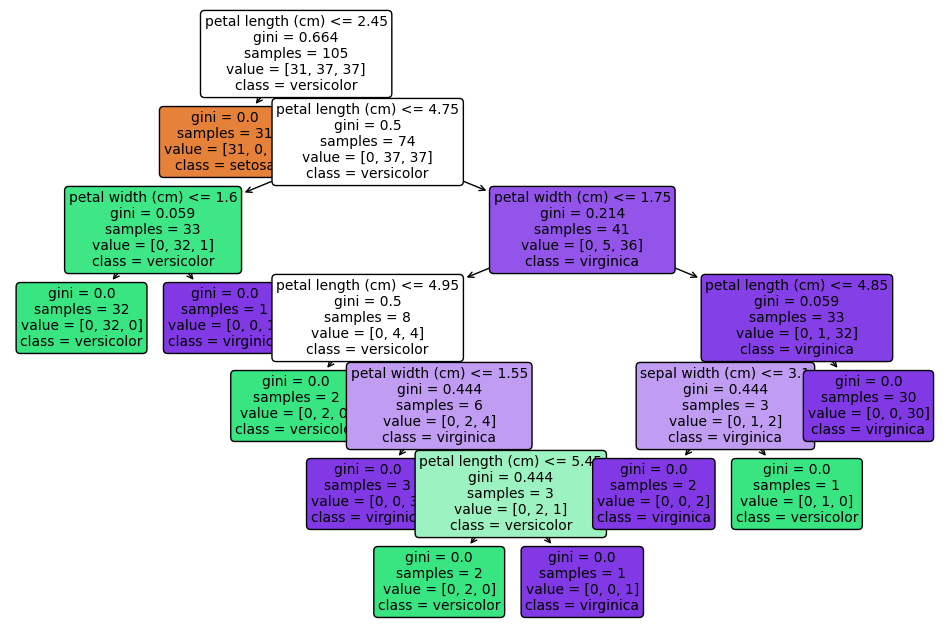

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'] ['setosa' 'versicolor' 'virginica']


In [27]:
from sklearn.datasets import load_iris

#1. Load Iris dataset
iris = load_iris()
x = iris.data
y = iris.target

# 2. Split the dataset into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

# 3. Initialize and train a Decision Tree classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# 4. Make predictions on the test set
y_pred = clf.predict(X_test)

# 5. Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 6. (Optional) Visualize the decision tree
plt.figure(figsize=(12,8))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=10)
plt.show()

print(iris.feature_names, iris.target_names)

### 4.2. Cancer

In [26]:
def load_data():
  # Bước 1: Đọc dữ liệu từ file CSV
    # Dữ liệu huấn luyện
    train_df = pd.read_csv("/content/drive/MyDrive/Machine Learning/datasets/labeled_cancer_data.csv")
    # Dữ liệu kiểm thử
    test_df = pd.read_csv("/content/drive/MyDrive/Machine Learning/datasets/labeled_test_data.csv")

    # Bước 2: Chuyển DataFrame thành mảng NumPy để dễ xử lý
    train = train_df.values
    test = test_df.values

    # Bước 3: Tách dữ liệu đầu vào (features) và nhãn (labels) cho tập huấn luyện
    X_train = train[:, 0:9].astype(float)   # Lấy 9 cột đầu làm đặc trưng (features)
    Y_train = train[:, -1].astype(float)    # Lấy cột cuối làm nhãn (0 = không ung thư, 1 = ung thư ác tính)
    print("Số lượng mẫu huấn luyện:", len(X_train))

    # Bước 4: Tách dữ liệu đầu vào và nhãn cho tập kiểm thử
    X_test = test[:, 0:9].astype(float)     # 9 đặc trưng đầu
    Y_test = test[:, -1].astype(float)      # Nhãn ở cột cuối
    print("Số lượng mẫu kiểm thử:", len(X_test))

    # Bước 5: Lấy tên các cột
    feature_names = list(train_df.columns[0:9])
    print(feature_names)

    # Bước 5: Trả về kết quả dưới dạng tuple
    return X_train, Y_train, X_test, Y_test, feature_names

Số lượng mẫu huấn luyện: 677
Số lượng mẫu kiểm thử: 15
['Cl.thickness', 'Cell.size', 'Cell.shape', 'Marg.adhesion', 'Epith.c.size', 'Bare.nuclei', 'Bl.cromatin', 'Normal.nucleoli', 'Mitoses']
Classification Report:
                 precision    recall  f1-score   support

  Không ung thư       0.86      0.86      0.86         7
Ung thư ác tính       0.88      0.88      0.88         8

       accuracy                           0.87        15
      macro avg       0.87      0.87      0.87        15
   weighted avg       0.87      0.87      0.87        15



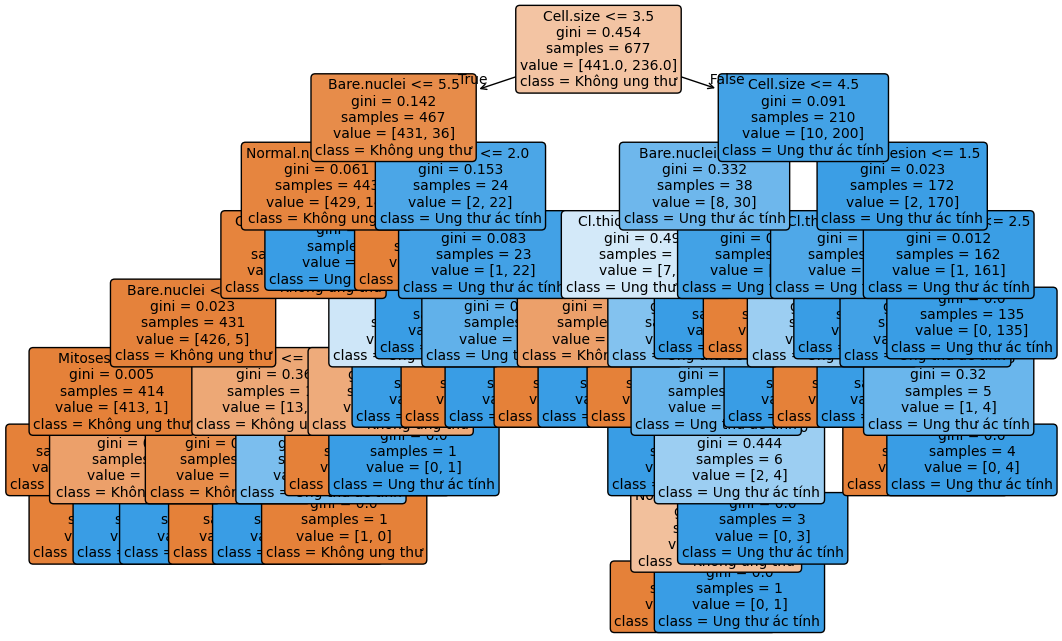

In [28]:
# 1.Tải dữ liệu huấn luyện và kiểm thử
X_train, Y_train, X_test, Y_test, feature_names = load_data()

# 2. Tạo danh sách phân loại
target_names = ['Không ung thư', 'Ung thư ác tính']

# 3. Initialize and train a Decision Tree classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, Y_train)

# 4. Make predictions on the test set
y_pred = clf.predict(X_test)

# 5. Print the classification report
print("Classification Report:")
print(classification_report(Y_test, y_pred, target_names=target_names))

# 6. (Optional) Visualize the decision tree
plt.figure(figsize=(12,8))
plot_tree(clf, feature_names=feature_names, class_names=target_names,
          filled=True, rounded=True, fontsize=10)
plt.show()